In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

In [46]:
df = pd.read_csv("diabetes.csv")

In [47]:
df.shape


(768, 9)

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [49]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [50]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [51]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [52]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [53]:

df["Outcome"].value_counts(normalize=True)

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

In [54]:
x = df.drop(columns=["Outcome"])
y = df["Outcome"]

In [55]:
y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

In [56]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

In [57]:
print("x shape", x.shape)
print("y shape", y.shape)
print("x_train shape", x_train.shape)
print("x_test shape", x_test.shape)
print("y_train shape", y_train.shape)
print("y_test shape", y_test.shape)

x shape (768, 8)
y shape (768,)
x_train shape (614, 8)
x_test shape (154, 8)
y_train shape (614,)
y_test shape (154,)


In [58]:
scaler = StandardScaler()

In [59]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [60]:
model = LogisticRegression()

In [61]:
model.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [62]:
y_train_pred = model.predict(x_train_scaled)
y_test_pred = model.predict(x_test_scaled)

y_test_prob = model.predict_proba(x_test_scaled)[:, 1]

In [63]:
x_train_scaled

array([[-0.85135507, -0.98013068, -0.40478372, ..., -0.60767846,
         0.31079384, -0.79216928],
       [ 0.35657564,  0.16144422,  0.46536842, ..., -0.30213902,
        -0.11643851,  0.56103382],
       [-0.5493724 , -0.50447447, -0.62232176, ...,  0.3725939 ,
        -0.76486207, -0.70759409],
       ...,
       [-0.85135507, -0.75815778,  0.03029235, ...,  0.77997981,
        -0.78607218, -0.28471812],
       [ 1.86648903, -0.31421198,  0.03029235, ..., -0.56948603,
        -1.01938346,  0.56103382],
       [ 0.05459296,  0.73223168, -0.62232176, ..., -0.31486983,
        -0.57700104,  0.30730824]], shape=(614, 8))

In [64]:
y_train

353    0
711    0
373    0
46     0
682    0
      ..
451    1
113    0
556    0
667    1
107    0
Name: Outcome, Length: 614, dtype: int64

In [65]:
print("y_train_pred:", y_train_pred)
print("-"*50)
print("y_test_pred:", y_test_pred)

y_train_pred: [0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 1
 0 1 1 1 0 1 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 1 0 0
 1 0 0 1 1 0 0 0 1 0 0 0 1 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 1 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0
 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 1 1 1 0 1
 0 0 1 0 0 0 0 1 1 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 1 1 0 0 0 1
 0 0 0 0 1 0 1 0 0 1 0 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1
 0 0 0 0 1 1 0 0 1 1 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0
 0 0 1 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 1 0 1 0 1 0 1 0 0 0 1 0 1 0
 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 0 1 1 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0
 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 1 1 1 0 0 1 0 0 0 0 0 1 0 0 0 1
 1 0 0 0 0 

In [66]:
y_test_prob

array([0.61667353, 0.11278116, 0.27253958, 0.28668164, 0.00448143,
       0.18904882, 0.46842913, 0.91697653, 0.10324589, 0.78113127,
       0.29613608, 0.63597286, 0.12786193, 0.09909978, 0.30866116,
       0.3507186 , 0.70392033, 0.09531777, 0.78252641, 0.23536029,
       0.16664796, 0.65671549, 0.18393873, 0.92643551, 0.52785293,
       0.01880984, 0.5887942 , 0.05766689, 0.33522309, 0.04281283,
       0.050227  , 0.05265587, 0.4613617 , 0.55726873, 0.8518256 ,
       0.13560198, 0.32840637, 0.0754743 , 0.74097894, 0.58611971,
       0.30527919, 0.10551335, 0.09793284, 0.29739564, 0.15755713,
       0.41726768, 0.17432501, 0.1229056 , 0.58461656, 0.52171584,
       0.65229788, 0.81955981, 0.3749456 , 0.07716855, 0.5118915 ,
       0.34345968, 0.7746283 , 0.23958681, 0.74641966, 0.14703567,
       0.76887073, 0.21935336, 0.00657952, 0.86809851, 0.0437365 ,
       0.15206912, 0.93705313, 0.02222134, 0.277012  , 0.6432003 ,
       0.19562609, 0.09992288, 0.32767586, 0.47411374, 0.04322

In [67]:
def print_metrics(title, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred) 
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(title)
    print(f"  Accuracy: {acc:.2%}")
    print(f"  Precision: {prec:.2%}")
    print(f"  Recall: {rec:.2%}")
    print(f"  F1-score: {f1:.2%}")

In [68]:
print_metrics("TRAIN METRICS", y_train, y_train_pred)
print_metrics("TEST METRICS", y_test, y_test_pred)

TRAIN METRICS
  Accuracy: 79.15%
  Precision: 75.90%
  Recall: 58.88%
  F1-score: 66.32%
TEST METRICS
  Accuracy: 71.43%
  Precision: 60.87%
  Recall: 51.85%
  F1-score: 56.00%


In [69]:
commat = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:")
print(commat)

Confusion Matrix:
[[82 18]
 [26 28]]


Confusion Matrix:
[[82 18]
 [26 28]]


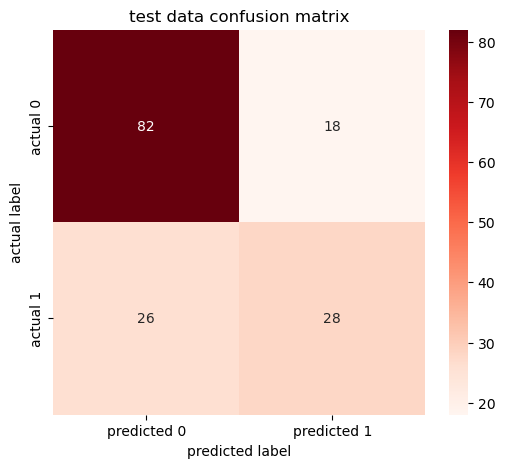

In [70]:
commat = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:")
print(commat)

plt.figure(figsize=(6, 5))
sns.heatmap(commat, annot=True, cmap="Reds", xticklabels=["predicted 0", "predicted 1"], yticklabels=["actual 0", "actual 1"])
plt.xlabel("predicted label")
plt.ylabel("actual label")
plt.title("test data confusion matrix")
plt.show()

ROC AUC score: 0.823


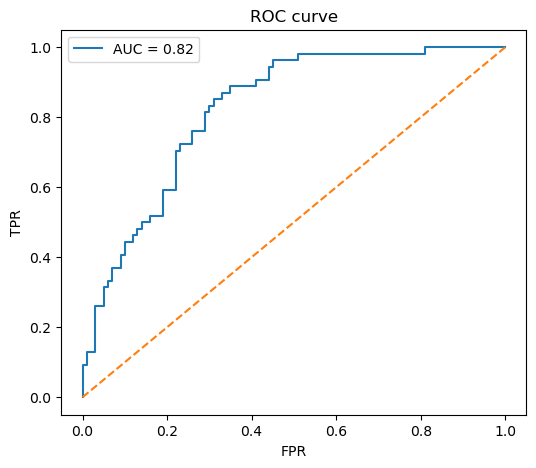

In [71]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
auc_score = roc_auc_score(y_test, y_test_prob)

print(f"ROC AUC score: {auc_score:.3f}")

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1], [0, 1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC curve")
plt.legend()
plt.show()

In [72]:
cols_with_zero = [col for col in x.columns if (x[col] == 0).any()]
print("Columns with zero values:", cols_with_zero)

Columns with zero values: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']


In [73]:
cols_with_zero.remove("Pregnancies")

In [74]:
print("Columns with zero values:", cols_with_zero)

Columns with zero values: ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']


In [75]:
for i in cols_with_zero:
    zero_count = (df[i] == 0).sum()
    print(f"{i}: {zero_count} zero values")

Glucose: 5 zero values
BloodPressure: 35 zero values
SkinThickness: 227 zero values
Insulin: 374 zero values
BMI: 11 zero values


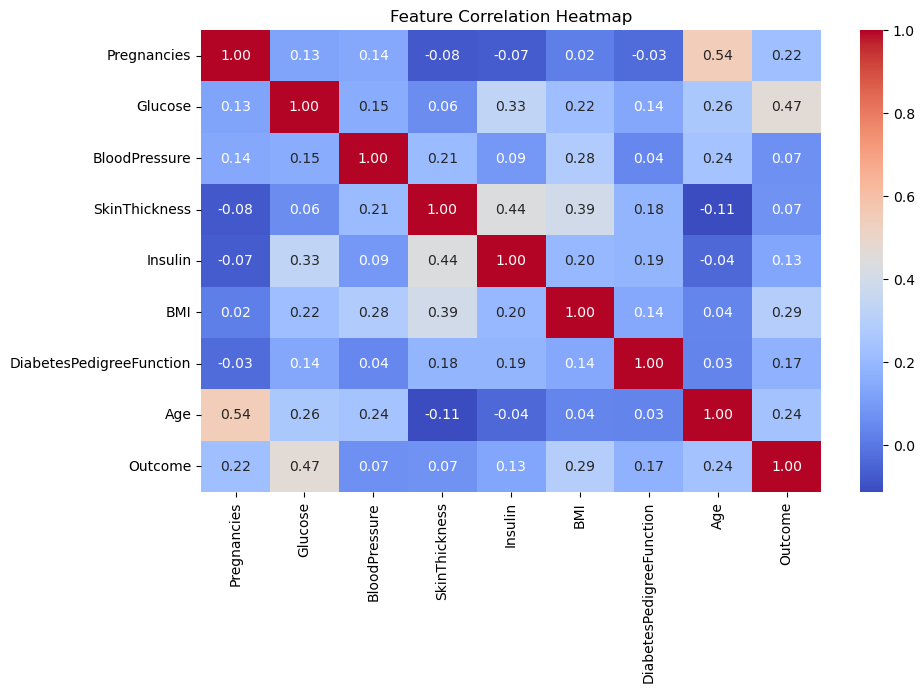

In [77]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()
